### First things first, let's run the cell below to load the libraries and set up the plotting defaults...   

In [1]:
import osiris

import numpy as np
import scipy

from osh5vis import osplot
from osh5io import read_h5
from osh5utils import fft
import osh5utils
import osh5io
import osh5def


import matplotlib.pyplot as plt
SMALL_SIZE=14
MEDIUM_SIZE=18
BIGGER_SIZE=22
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title 

/usr/local/oshun/osh5def.py:417: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if axes is () or axes[0] is None:  # axes is none, numpy default is to reverse the order


## Landau Damping with UPIC-ES





The normalization for UPIC are as follows. Note that  Δ  is the size of the cell:

Time:  𝑡′=𝑡𝜔𝑝𝑒 
Frequency:  𝜔′=𝜔𝜔𝑝 

Position:  𝑥⃗ ′=𝜔𝑝𝑐𝑥⃗ /Δ 

Velocity:  𝑣⃗ ′=𝑣⃗ 𝜔𝑝Δ 

Electric field:  𝐸⃗ ′=𝑒𝑚𝑒1𝜔2𝑝Δ𝐸⃗  

(There is no magnetic field as the code is purely electrostatic)

### Introduction

Waves are a fundamental collective process in plasmas. The plasma state is rich in wave phenomena. One of the basic properties of plasmas, charge neutrality, is mediated by Langmuir waves. In most plasmas of interest, the ions are much heavier than the electrons and thus the ions move little compared to the electrons. When the electrons are displaced, an electric field develops to maintain charge neutrality, which accelerates the electrons back towards the ions. The electrons will overshoot and effectively slosh around the stationary ions. These oscillations are known by a variety of names: Langmuir oscillations, space charge waves, or simply plasma oscillations. For a stationary cold plasma, there are non-propagating modes at the plasma frequency. These modes become propagating modes when the plasma drifts at a constant speed. These can be studied in the fluid description if we choose an equation of state, i.e., if we have a model for pressure as a function of density and temperature.

#### Fluid Dispersion Relation
We consider a plasma with warm electrons and cold ions. First we choose the ideal equation of state, $P=\gamma \tilde{n}_e T_e$, where $\gamma \approx 3$ is the adiabatic index obtained from kinetic theory. We can then write the five linearized fluid equations. First we have the Navier-Stokes equations for both the electrons and ions, respectively:

\begin{equation}
		\frac{\partial}{\partial t}\tilde{\mathbf{v}}_e=-\frac{e}{m_e}\tilde{\mathbf{E}}-\frac{\gamma T_e}{m_e n_{0e}}\nabla \tilde{n}_e\\
		\frac{\partial}{\partial t} \tilde{\mathbf{v}}_i=\frac{Ze}{m_i}\tilde{\mathbf{E}}.
\end{equation}

The continuity equations are

\begin{equation}
		\frac{\partial}{\partial t}\tilde{n}_e+\nabla \cdot [n_{0e}\tilde{\mathbf{v}}_e]=0\\
		\frac{\partial}{\partial t}\tilde{n}_i+\nabla \cdot [n_{0i}\tilde{\mathbf{v}}_i]=0,
\end{equation}

and finally Poisson's equation is given as
\begin{equation}
	\nabla \cdot \tilde{\mathbf{E}}=-4 \pi e (\tilde{n}_e-Z\tilde{n}_i).
\end{equation}
We then take the divergence of the Navier-Stokes equations and the time derivative of the continuity equations and combine. We then go Fourier space by assuming plane wave solutions, i.e., $\partial_t \rightarrow -i\omega$ and $\nabla \rightarrow ik$. Solving the resulting equation for $\tilde{n}_e$ gives
\begin{equation}
	\tilde{n}_e=\frac{-\frac{e n_{0e}}{m_e}i\mathbf{k}\cdot\tilde{\mathbf{E}}}{\omega^2-\frac{\gamma T_e k^2}{m_e n_{0e}}}
\end{equation}
We get a similar result for ions, but without the pressure term. We then substitute these into Poisson's Equation and collect terms to get
\begin{equation}
	\left( 1-
    \frac{\omega_{pi}^2}{\omega ^2} 
    - \frac{\omega_{pe}^2}{\omega^2}
    \left( 1 + \frac{\gamma T_e k^2}{\omega^2 m_e n_{0e}} \right)    
    \right) 
    \mathbf{k}\cdot\tilde{\mathbf{E}}=0.
\end{equation}
Since $\nabla \cdot \tilde{\mathbf{D}} = \nabla \cdot (\epsilon \tilde{\mathbf{E}}) = \epsilon \mathbf{k} \cdot \tilde{\mathbf{E}}$, the term in parenthesis is then our dielectric constant. Setting this equal to zero and assumes the ion mass to be infinite (and ignore the $\omega_{pi}$ contribution) gives the (Bohm-Gross) dispersion relation,
\begin{equation}
	\omega^2=\omega_{pe}^2+\gamma \bar{v}_e^2 k^2,
\end{equation}
where $\bar{v}_e^2=T_e/m_e$, and we have neglected the ion contribution because it is small compared to the electron contribution for Langmuir waves. So we see that the pressure term provides an additional term to the dispersion relation (the stationary solution is just $\omega^2=\omega_{pe}^2$).

### Kinetic Dispersion Relation:

The Langmuir description (shown above) lacks kinetic damping. A more accurate (and complete) dispersion relation, which includes kinetic effects, can be obtained by treating the plasma wave problem as an initial value problem and using a Laplace transform in time, which allows for damping.  Following this line of logic, the plasma dispersion becomes: 

\begin{equation}
\epsilon(\omega,k) = 1 + \sum_{s} \chi_s(\omega,k)
\end{equation}

with no approximation, and taking causality into account, the plasma susceptibility $\chi_s$ can be written as (the full derivation can be found in the classic paper by Landau):
\begin{equation}
\chi_s (\omega,k) = \frac{1}{2} \left( \frac{\omega_{p,s}}{k v_{t,s} } \right)^2 
Z'(\frac{\omega} {\sqrt{2}k v_{t,s}} )
\end{equation}
Therefore, for a Maxwellian plasma and infinitely massive, cold ion, the plasma dispersion relation becomes:
\begin{equation}
1 - 0.5 * \left( \frac{\omega_{p,e}}{k v_{t,e} } \right)^2 
Z'(\frac{\omega} {\sqrt{2}k v_{t,e}} ) = 0
\end{equation}

The above expression do not yield to easy expresssions, but some asymptotic limits are available.  For example, for very large phase velocities, or $k \lambda_D < 0.25$, the Bohm-Gross dispersion relation (shown above) works very well.  

In the **weak damping limit**, one can obtain an approximation for the damping rate.  This is given both in the original paper by Landau (equation (1.2)) and a more accurate expression was also obtained by J. D. Jackson in 1960 (equation (6.3) in J. D. Jackson, J. Nucl. Eng. Part C Plasma Physics 1, 171 (1960).) For a small range of $k \lambda_D$, typically $k \lambda_D < 0.5$ (as shown in Figure (3) of the Jackson paper), the damping rate can be approximated by the expression:  

\begin{equation}
 \gamma /\omega << 1
\end{equation}



\begin{equation}
\gamma = \frac{ \epsilon_I(k,\omega(k))}
{\frac{\partial}{\partial \omega} \epsilon_R(k,\omega(k))}\\
\end{equation}

\begin{equation}
\gamma = - \sqrt{\frac{\pi}{8}} \frac{1}{(k \lambda_D)^3} \ exp(-\frac{2}{3}) \ \
exp \left(- \left({\frac{k_D}{\sqrt{2}k}}\right)^2 \right)
\end{equation}

Below we first plot the exact result vs the Jackson estimate for a large range of $k \lambda_D$.








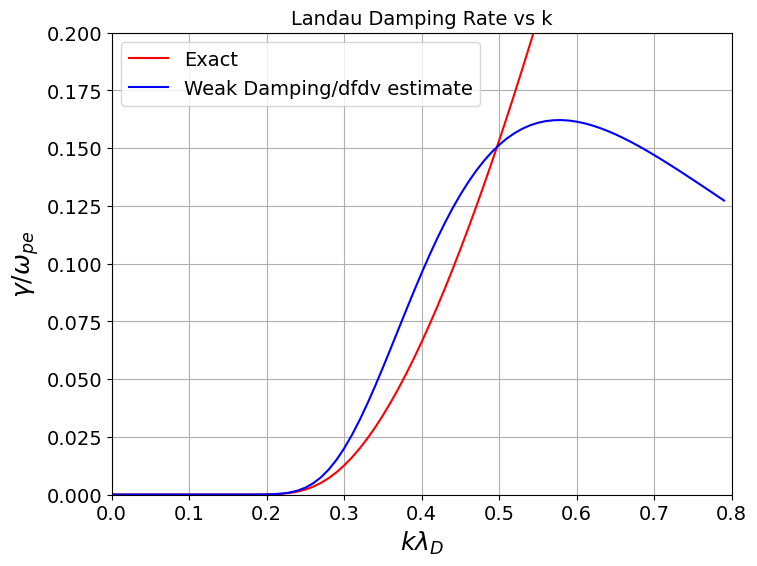

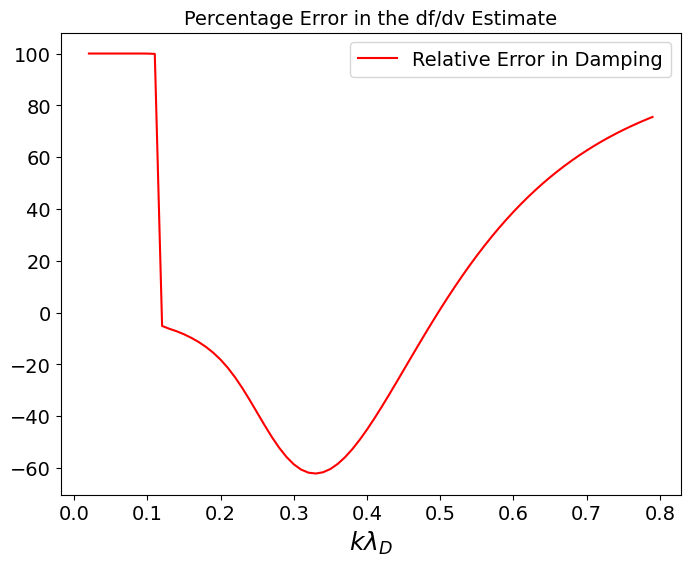

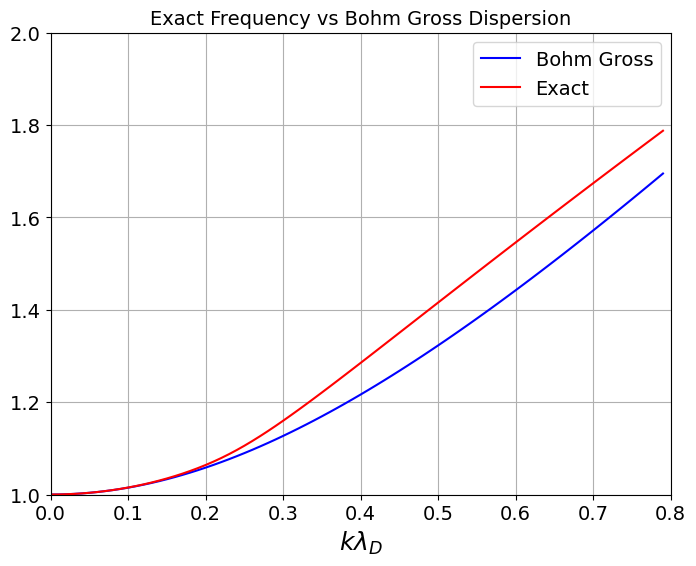

In [2]:
karray=np.arange(0.0,0.8,0.01)

[damping, frequency]=osiris.landau(karray)
damping_estimate=np.sqrt(np.pi/8)*1.0/(karray*karray*karray+1e-5)*np.exp(-1.5)*np.exp(-1/(2*karray*karray+1e-5))
damping_estimate[0]=0.0
frequency[0]=1.0

# Plot Landau damping rate vs k
plt.figure(figsize=(8,6))
plt.plot(karray,np.abs(damping),'r',label='Exact')
plt.plot(karray,damping_estimate,'b',label='Weak Damping/dfdv estimate')
plt.xlabel('$k \lambda_D$')
plt.ylabel('$\gamma/\omega_{pe}$')
plt.title('Landau Damping Rate vs k')
plt.xlim((0,0.8))
plt.ylim((0,0.2))
plt.grid()
plt.legend()
plt.show()

# Plot percent error in the estimated damping rate
plt.figure(figsize=(8,6))
plt.plot(karray[2:],100*(1-np.abs(damping_estimate[2:]/np.abs(damping[2:]))),'r',label='Relative Error in Damping')
plt.xlabel('$k \lambda_D$')
plt.title('Percentage Error in the df/dv Estimate')
plt.legend()
plt.show()

# Calculate exact vs approx Landau damping for later
landau_exact=scipy.interpolate.interp1d(karray,np.abs(damping),kind='cubic')
landau_estimate=scipy.interpolate.interp1d(karray,damping_estimate,kind='cubic')

frequency_exact = scipy.interpolate.interp1d(karray,frequency,kind='cubic')

# Plot exact frequency vs Bohm Gross frequency
bohm_gross=np.sqrt(1+3*karray*karray)
# print(bohm_gross)

plt.figure(figsize=(8,6))
plt.plot(karray,bohm_gross,'b',label='Bohm Gross')
plt.plot(karray, frequency,'r', label='Exact')
plt.title('Exact Frequency vs Bohm Gross Dispersion')
plt.xlabel('$k \lambda_D$')
plt.xlim((0,0.8))
plt.ylim((1,2))
plt.grid()
plt.legend()
plt.show()

## UPIC Simulation:


###  CASE 1:  $k\lambda_D = 0.319$

The simulation is done with the electrostatic PIC code UPIC-ES.  The simulation is periodic in 1D with 256 cells across.  There are 4 million ($2^{22}$) particles in the simulation box, which translates to roughly 16,384 particles per cell.  The initial thermal velocity is 1, which means the grid size is exactly one Debye length.


A external traveling electric field at mode 13 ($k \lambda_D = 0.319$) is applied to the system at t=0.  The frequency of the wave is obtained from the kinetic dispersion relation ($\omega/\omega_p = 1.18$).  The external electric field is left on for a duration of $3.5 \omega_{pe}^{-1}$, and then the system is allowed to evolve self-consistently.  

To obtain the damping rate, we observe the temporal behavior of the wave that is excited by the external driver and perform an exponential fit, using both the exact root and also the $df/dv$ estimate.




In [3]:
dirname = 'landau-kd035-4million'

osiris.run_upic_es(rundir=dirname,inputfile='landau-kd035-4million.txt',np=2)
#osiris.run_upic_es_subtech(rundir=dirname,inputfile='landau-kd035.txt')

run_upic_es completed normally


####  In the cell below we look at the overall time history of the electrostatic potential, you can see the mode driven at k=.319.

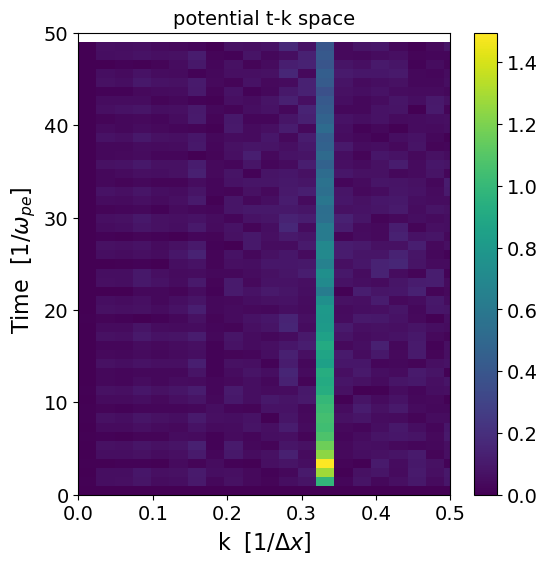

In [4]:
dirname = 'landau-kd035-4million'

osiris.plot_tk_arb(dirname,'Ex',klim=0.5,tlim=50)
#osiris.plot_tk_arb(dirname+'-nodriv','Exsubs',klim=0.5,tlim=50)

#### Here we look at the time history of mode 13, the mode that is driven in this simulation, and compare the damping rate against the exact solution, and the df/dv estimate given by Jackson.

1.101344032812193


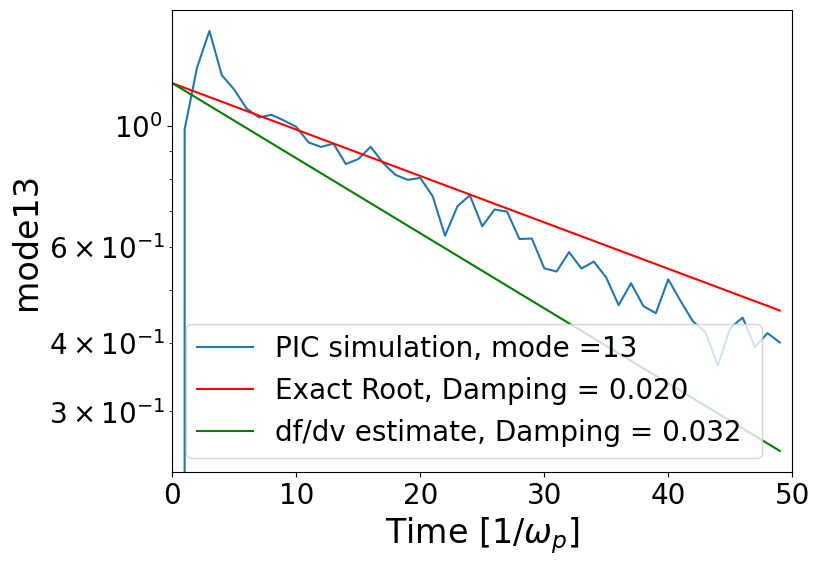

In [5]:
modenum = 13
theory_exact=landau_exact(2*np.pi/256.0 * modenum)
theory_estimate=landau_estimate(2*np.pi/256.0 * modenum)
print(frequency_exact(2*np.pi/256*10))

dirname = 'landau-kd035-4million'
# osiris.plot_tk_landau_theory(dirname,'Ex',modeno=13,theory1=theory_exact,theory2=theory_estimate,init_amplitude=1.18,tlim=50)
osiris.plot_tk_landau_theory(dirname,
                             'Ex',
                             modeno=13,
                             theory1=theory_exact,
                             theory2=theory_estimate,
                             init_amplitude=1.2,
                             tlim=50)

###  CASE 2:  $k\lambda_D = 0.319$ using the subtraction technique

This simulation is also done with the electrostatic PIC code UPIC-ES using the same parameters as above, but now we use the subtraction technique in order to reduce the number of particles we need to use.  In this simulation, we only use approximately 100,000 particles ($2^{17}$), or 512 particles per cell rather than 16384 particles per cell.

Here is what the mode amplitudes are for a regular simulation with $2^{17}$ particles:

run_upic_es completed normally


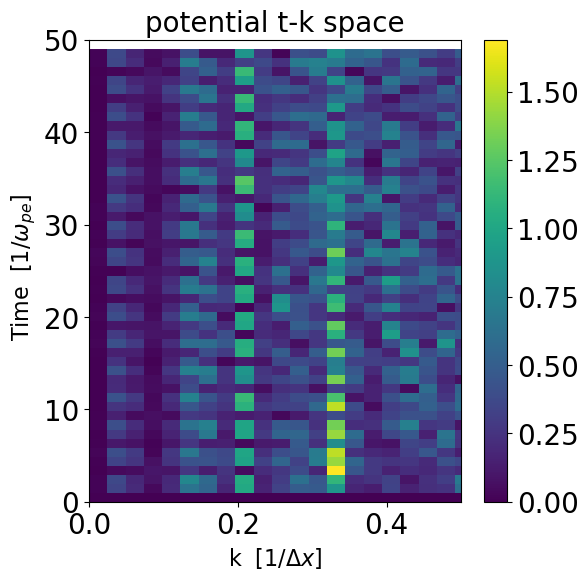

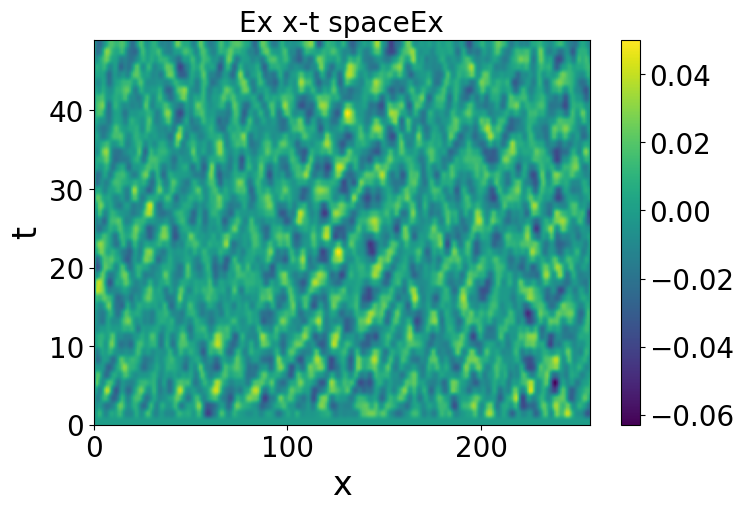

In [6]:
dirname = 'landau-kd035'

osiris.run_upic_es(rundir=dirname,inputfile='landau-kd035.txt',np=2)
osiris.plot_tk_arb(dirname,'Ex',klim=0.5,tlim=50)
osiris.plot_xt_arb(dirname,'Ex')

In [44]:
#
#
# Here are some basic functions to generate filenames for Grid, Phase Space, and Particle data, respectively
#
#

def file_name_field(path,field,file_no):
    filename=path+'/DIAG/'+field+'/'+field+'-0_'+repr(file_no).zfill(6)+'.h5'
    # print(filename)
    return(filename)
    
 
def file_name_phase(path,file_no):
    filename=path+'/DIAG/Vx_x/vx_x_'+repr(file_no).zfill(6)+'.h5'
    # print(filename)
    return(filename)


And here is what the mode amplitudes are when we take the electric field from the above simulation and subtract off the electric field from another simulation that is identical in every way except that it is undriven.

run_upic_es completed normally


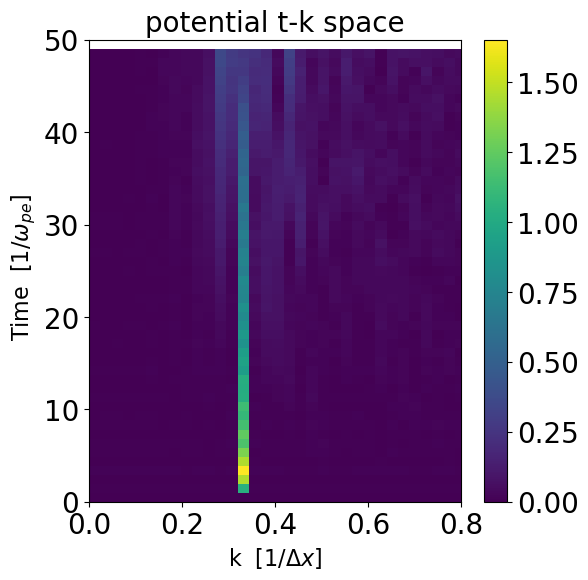

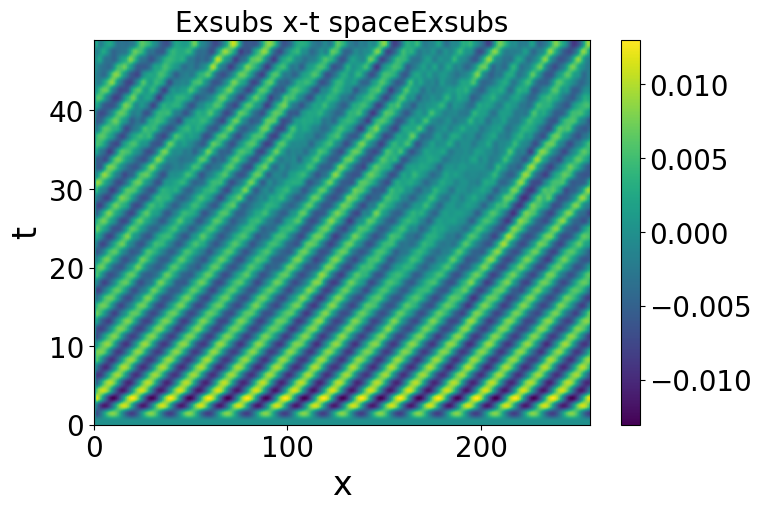

In [7]:
dirname = 'landau-kd035'

osiris.run_upic_es_subtech(rundir=dirname,inputfile='landau-kd035.txt',np=2)
osiris.plot_tk_arb(dirname+'-nodriv','Exsubs',klim=0.8,tlim=50)
osiris.plot_xt_arb(dirname+'-nodriv','Exsubs')

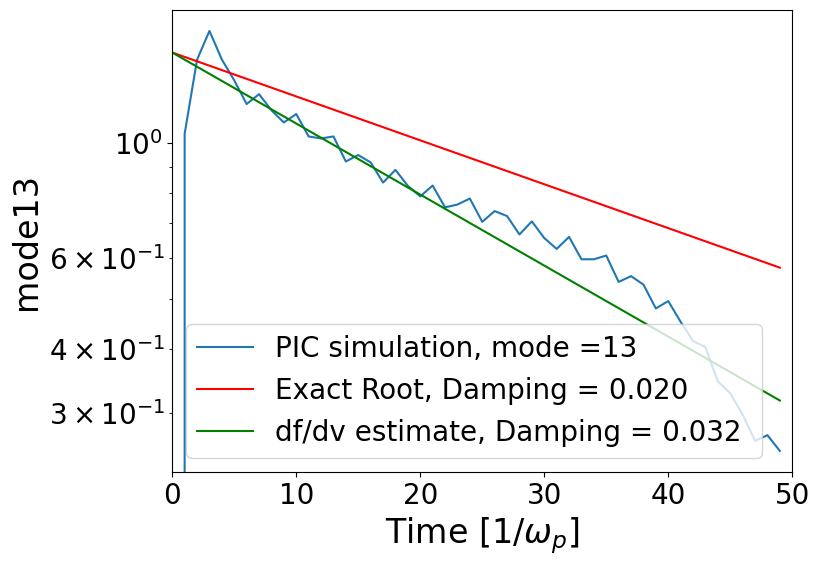

In [8]:
modenum = 13
theory_exact=landau_exact(2*np.pi/256.0 * modenum)
theory_estimate=landau_estimate(2*np.pi/256.0 * modenum)

dirname = 'landau-kd035'
osiris.plot_tk_landau_theory(dirname+'-nodriv',
                             'Exsubs',
                             modeno=13,
                             theory1=theory_exact,
                             theory2=theory_estimate,
                             init_amplitude=1.5,tlim=50)


                            

###  CASE 3:  $k\lambda_D = 0.245$

Here we investigate the behavior of a linear plasma wave at lower $k \lambda_D$.   In this case, $k \lambda_D$ =0.245.  The driver frequency is $\omega/\omega_{pe} = 1.059$.   

Because the damping rate here is much lower than the first case (0.002 instead of 0.02 $\omega_pe$), we increase the simulation time from $T=50 \omega_p^{-1}$ to $T=100 \omega_p^{-1}$.  The driven wave theoretically damps by only a factor of approximately $\exp(0.2)=1.2$ in that time. 

Here again we use the subtraction technique for the much faster simulation time.

In [22]:
dirname = 'landau-kd0245'

osiris.run_upic_es_subtech(rundir=dirname,inputfile='landau-kd0245.txt')

run_upic_es completed normally


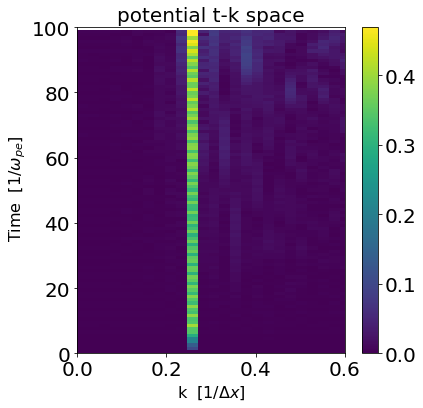

In [23]:
dirname = 'landau-kd0245'

osiris.plot_tk_arb(dirname+'-nodriv','Exsubs',klim=0.6,tlim=100)

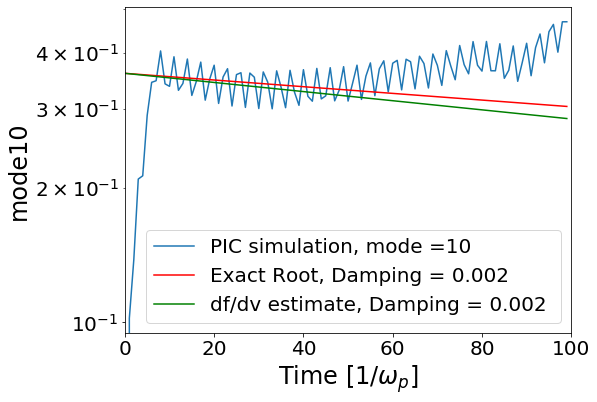

In [32]:
modenum = 10
theory_exact=landau_exact(2*np.pi/256.0 * modenum)
theory_estimate=landau_estimate(2*np.pi/256.0 * modenum)

dirname = 'landau-kd0245'
osiris.plot_tk_landau_theory(dirname+'-nodriv','Exsubs',modeno=10,
                             theory1=theory_exact,theory2=theory_estimate,
                             init_amplitude=0.36,tlim=100)

###  CASE 4:  $k\lambda_D = 0.54$

Here we investigate the behavior of a linear plasma wave at a much higher $k \lambda_D$.   In this case, $k \lambda_D$ =0.54.  The driver frequency (taken from the exact solution) is $\omega/\omega_{pe} = 1.46$.   

Because the damping rate here is 9 times higher than the first case (0.18 instead of 0.02 $\omega_pe$).  We reduce the simulation time from $T=50 \omega_p^{-1}$ to $T=25 \omega_p^{-1}$.  The driven wave damps by a factor of approximately $\exp(4.5)=90.02$ in that time. 

Here again we use the subtraction technique for the much faster simulation time.

In [33]:
dirname = 'landau-kd054'

#osiris.run_upic_es(rundir=dirname,inputfile='landau-kd054.txt')
osiris.run_upic_es_subtech(rundir=dirname,inputfile='landau-kd054.txt')

run_upic_es completed normally


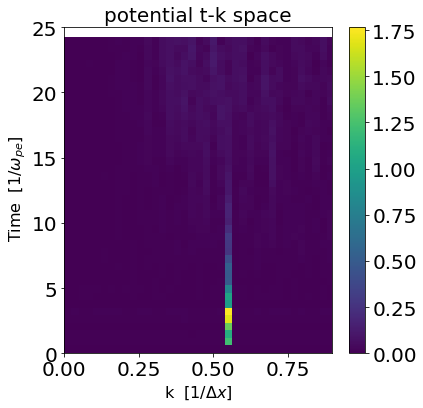

In [34]:
dirname = 'landau-kd054'
import matplotlib.colors
# osiris.plot_tk_arb(dirname,'Ex',klim=0.6,tlim=25)
osiris.plot_tk_arb(dirname+'-nodriv','Exsubs',klim=0.9,tlim=25)

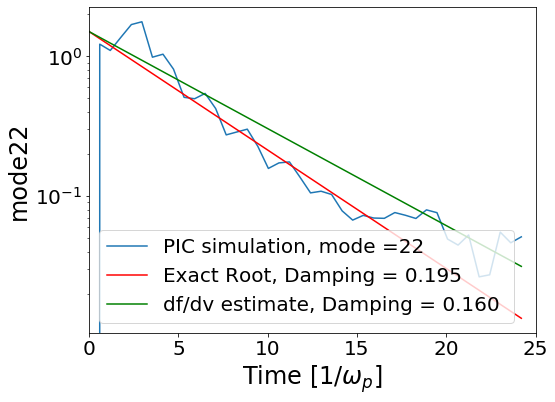

In [36]:
modenum = 22
theory_exact=landau_exact(2*np.pi/256.0 * modenum)
theory_estimate=landau_estimate(2*np.pi/256.0 * modenum)

dirname = 'landau-kd054'
# osiris.plot_tk_landau_theory(dirname,'Ex',modeno=22,theory1=0.18,theory2=0.14,init_amplitude=1.3,tlim=25)
osiris.plot_tk_landau_theory(dirname+'-nodriv','Exsubs',modeno=22,
                             theory1=theory_exact,theory2=theory_estimate,
                             init_amplitude=1.5,tlim=25)

### Some questions to consider:
    
    * How good is the df/dv estimate?  
    * What happens if the driver amplitude increases?  What are some nonlinear effects?


## Simulation Sandbox for Landau Damping:

Here you can excite a plasma wave and look at Landau damping.  You can specify 

* amplitude
* wave number
* frequency
* duration of the simulation

these simulations use a lot of particles to reduce noise so they take some time to run.  Please be patient.



In [21]:
# For reference
import ipywidgets
def kldAndFreq(modenum=13):
    print('k*lambda_D = {:.3f}'.format(2*np.pi/256*modenum))
    print(r'w_resonant = {:.3f}'.format(np.sqrt(1+2*(2*np.pi/256*modenum)**2)))
ipywidgets.interact(kldAndFreq,modenum=(1,25));

interactive(children=(IntSlider(value=13, description='modenum', max=25, min=1), Output()), _dom_classes=('wid…

In [37]:
osiris.landau_damping_widget()

interactive(children=(Text(value='landau-kd035.txt', description='Template Input File:', layout=Layout(width='…